# **Linear Regression**

MAE: 269.4804732263763
MSE: 399253.99172389676
RMSE: 631.8654854665641


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


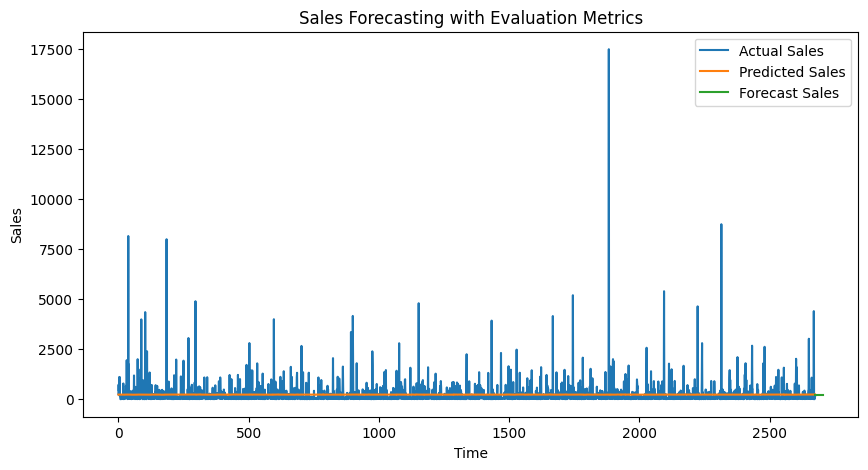

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/rohitsahoo/sales-forecasting/train.csv")

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

# Remove missing values
df = df.dropna(subset=['Order Date', 'Ship Date'])

# Feature engineering
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Day'] = df['Order Date'].map(pd.Timestamp.toordinal)

# Features & target
X = df[['Day', 'Delivery Days']]
y = df['Sales']
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

# 🔮 Future forecasting
future_days = []
last_day = df['Day'].max()

for i in range(1, 31):
    future_days.append([last_day + i, df['Delivery Days'].mean()])

forecast = model.predict(future_days)

# 📈 Plot graph
plt.figure(figsize=(10,5))

# Actual vs Predicted
plt.plot(y.values, label="Actual Sales")
plt.plot(pred, label="Predicted Sales")

# Future forecast
plt.plot(range(len(y), len(y)+30), forecast, label="Forecast Sales")

plt.xlabel("Time")
plt.ylabel("Sales")
plt.title("Sales Forecasting with Evaluation Metrics")
plt.legend()
plt.show()

# **Methodology**
Order Date and Ship Date were preprocessed using datetime conversion. A new feature called “Delivery Days” was created by calculating the difference between shipping and order dates. Linear Regression model was used for predicting future sales trends.